In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

dataset = pd.read_csv("../dataset/featured_dataset.csv")

dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539226 entries, 0 to 539225
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   year               539226 non-null  int64  
 1   make               539226 non-null  object 
 2   model              539226 non-null  object 
 3   trim               539226 non-null  object 
 4   body               536458 non-null  object 
 5   transmission       476694 non-null  object 
 6   vin                539226 non-null  object 
 7   state              539226 non-null  object 
 8   condition          539226 non-null  float64
 9   odometer           539226 non-null  float64
 10  color              539226 non-null  object 
 11  interior           539226 non-null  object 
 12  seller             539226 non-null  object 
 13  mmr                539226 non-null  float64
 14  sellingprice       539226 non-null  float64
 15  saledate           539226 non-null  object 
 16  sa

In [2]:
dataset.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,sale_year,vehicle_age,mmr_vs_sp,mmr_vs_sp_percent
0,2015,kia,sorento,lx,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,2014-12-16 04:30:00+00:00,2014,-1,1000.0,4.88
1,2015,kia,sorento,lx,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,2014-12-16 04:30:00+00:00,2014,-1,700.0,3.37
2,2014,bmw,3 series,328i sulev,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,2015-01-14 20:30:00+00:00,2015,1,-1900.0,-5.96
3,2015,volvo,s60,t5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,2015-01-28 20:30:00+00:00,2015,0,250.0,0.91
4,2014,bmw,6 series gran coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,2014-12-18 04:30:00+00:00,2014,0,1000.0,1.52


In [3]:
#1. Total revenue through years

dataset["sellingprice"].sum()

np.float64(7371675733.0)

In [4]:
#2. Total units sold through years.

dataset["vin"].size

539226

In [5]:
#3. Top 10 highest units sold company (all time).

top_10_vehicles = (dataset.groupby(["make"])["vin"]
                   .agg("count")
                   .sort_values(ascending = False)
                   .reset_index(name = "unit_sold")
                   .head(10))
top_10_vehicles

,make,unit_sold
0,ford,92311
1,chevrolet,59562
2,nissan,53297
3,toyota,39419
4,dodge,30460
5,honda,26966
6,hyundai,21578
7,bmw,20217
8,kia,17890
9,chrysler,17237


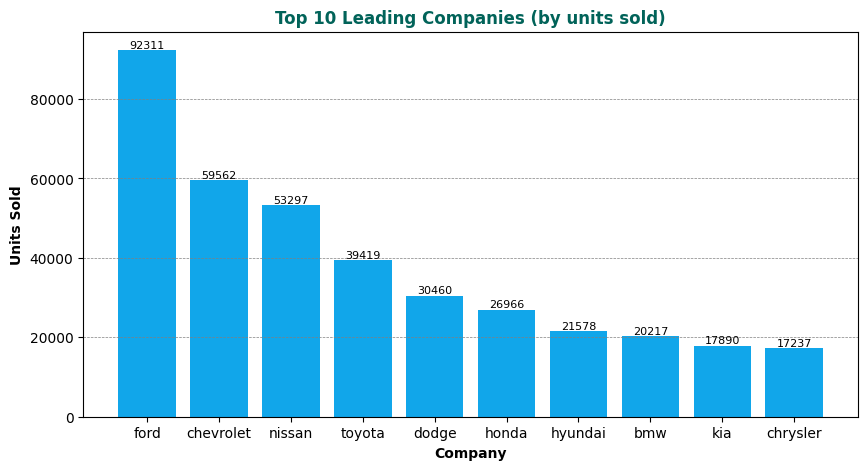

In [6]:
# plotting graph

x_axis = top_10_vehicles["make"]
y_axis = top_10_vehicles["unit_sold"]

plt.figure(figsize = (10, 5))

bars = plt.bar(x_axis, y_axis, color = "#11a6eaff")

plt.bar_label(bars, fontsize = 8)
plt.grid(axis = "y" , linestyle = "--", linewidth = 0.5, color = "grey")

plt.title("Top 10 Leading Companies (by units sold)", loc = "center", fontweight = "bold", color = "#016359")
plt.xlabel("Company", loc = "center", fontweight = "bold")
plt.ylabel("Units Sold", fontweight = "bold")

plt.savefig("../charts/top_10_companies_by_units_sold")
plt.show()

In [7]:
#4. Top 10 unit sold states (all time).

top_10_states = (dataset.groupby(["state"])["vin"]
                 .agg("count")
                 .sort_values(ascending = False)
                 .reset_index(name = "units_sold")
                 .head(10))
top_10_states

,state,units_sold
0,fl,80362
1,ca,70061
2,pa,52431
3,tx,44271
4,ga,33281
5,nj,27115
6,il,22987
7,oh,20789
8,nc,20747
9,tn,19875


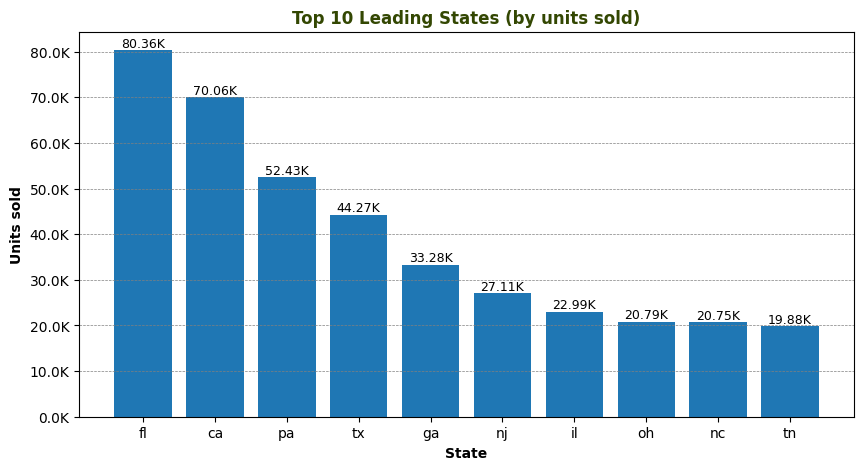

In [8]:
# plotting graph

x_axis = top_10_states["state"]
y_axis = top_10_states["units_sold"]

plt.figure(figsize = (10, 5))

bars = plt.bar(x_axis, y_axis)

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.grid(axis = "y", linewidth = 0.5, color = "grey", linestyle = "--")

plt.title("Top 10 Leading States (by units sold)", fontweight = "bold", color = "#334702")
plt.xlabel("State", fontweight = "bold")
plt.ylabel("Units sold", fontweight = "bold")

plt.bar_label(bars, 
              labels = [f"{x/1000:.2f}K" for x in bars.datavalues],
              fontsize = 9)

plt.savefig("../charts/top_10_states_by_units_sold")
plt.show()

In [9]:
#5. Median age of vehicle (all time).

dataset["vehicle_age"].agg("median")

np.float64(3.0)

In [10]:
#6. Highest units sold vehicle [make, body, trim] (all time).

top_10_make_model = (dataset.groupby(["make", "model"])["vin"]
.agg("count")
.sort_values(ascending = False)
.reset_index(name = "unit_sold")
.head(10)
)

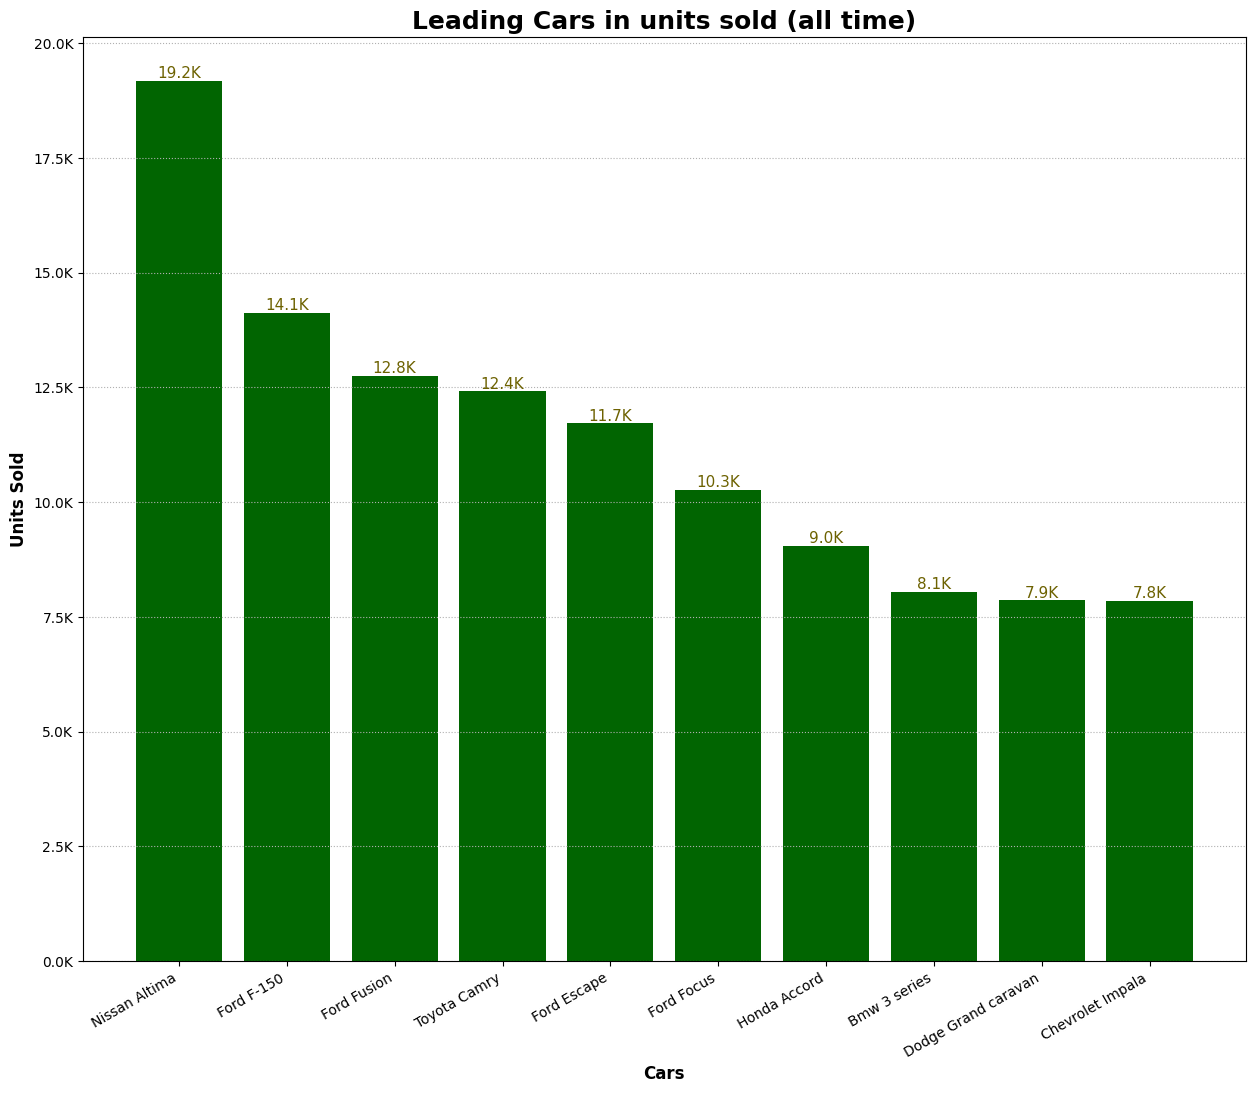

In [11]:
#6. Graph

x_axis = top_10_make_model["make"].str.capitalize() + " " + top_10_make_model["model"].str.capitalize()
y_axis = top_10_make_model["unit_sold"]

plt.figure(figsize = (15, 12))

bars = plt.bar(x_axis, y_axis, color = "#016501")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

plt.bar_label(bars,
              labels = [f"{x/1000:.1f}K" for x in bars.datavalues],
              color = "#6D6201",
              fontsize = 11)

plt.xticks(rotation = 30, ha = "right")
plt.grid(axis = "y", linewidth = 0.8, linestyle = ":")

plt.title("Leading Cars in units sold (all time)", fontsize = 18, fontweight = "bold")
plt.xlabel("Cars", fontsize = 12, fontweight = "bold")
plt.ylabel("Units Sold", fontsize = 12, fontweight = "bold")

plt.savefig("../charts/top_10_cars_by_units_sold.png")
plt.show()

In [12]:
#7. Past 10 years year wise, leading company in units sold.

year_group = (dataset.groupby(["year", "make"])["vin"]
              .count()
              .reset_index(name = "units"))

year_group


,year,make,units
0,1984,chevrolet,1
1,1985,chevrolet,2
2,1986,chevrolet,1
3,1987,mercedes,1
4,1989,chevrolet,2
...,...,...,...
893,2015,smart,3
894,2015,subaru,235
895,2015,toyota,236
896,2015,volkswagen,63


In [13]:
past_years_top_company = year_group.loc[year_group.groupby(["year"])["units"].idxmax()]
past_10_years_top_company = year_group.loc[year_group.groupby(["year"])["units"].idxmax()].tail(10)

In [14]:
past_10_years_top_company["make"].unique()

array(['ford', 'chevrolet', 'nissan', 'kia'], dtype=object)

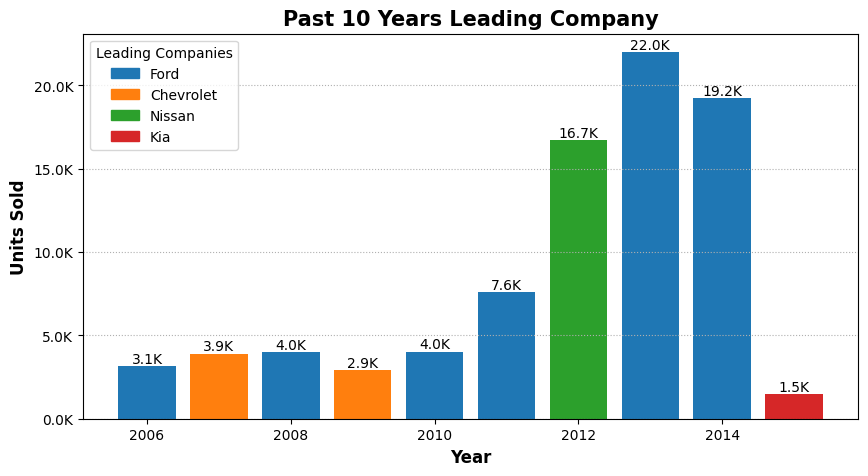

In [113]:
x_axis = past_10_years_top_company["year"]
y_axis = past_10_years_top_company["units"]

unique_companies = past_10_years_top_company["make"].unique()

# Alloting colour to companies
colors = plt.cm.tab10(range(len(unique_companies)))
color_map = dict(zip(unique_companies, colors))
color_bars = past_10_years_top_company["make"].map(color_map)

# Defining structure of graph
plt.figure(figsize = (10, 5))
bars = plt.bar(x_axis, y_axis, color = color_bars)
plt.grid(axis = "y", linestyle = ":", linewidth = 0.8)
plt.bar_label(bars,
              labels = [f"{x/1000:.1f}K" for x in bars.datavalues])

# Formatting
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x/1000:.1f}K")
)

# Contents of legend
legend_items = [Patch(color = color_map[company], label = company.capitalize()) for company in unique_companies]

plt.legend(handles = legend_items, title = "Leading Companies")

# Titles
plt.title("Past 10 Years Leading Company", fontsize = 15, fontweight = "bold")
plt.xlabel("Year", fontsize = 12, fontweight = "bold")
plt.ylabel("Units Sold", fontsize = 12, fontweight = "bold")

plt.savefig("../charts/past_10_year_leading_companies.png")
plt.show()

In [ ]:
#8. Past year (all time) leading companies distribution.

leading_company_distribution = past_years_top_company["make"].value_counts().reset_index(name = "frequency")

leading_company_distribution["percent_share"] = round(((leading_company_distribution["frequency"] /
                                                  leading_company_distribution["frequency"].sum())* 100)
                                                  , 2)

leading_company_distribution

,make,frequency,percent_share
0,ford,13,41.94
1,chevrolet,7,22.58
2,toyota,5,16.13
3,honda,3,9.68
4,mercedes,1,3.23
5,nissan,1,3.23
6,kia,1,3.23


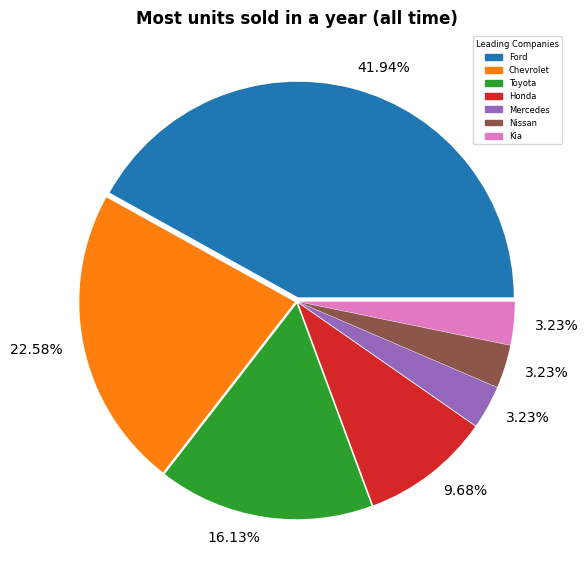

In [111]:
values = leading_company_distribution["frequency"]
comapanies = leading_company_distribution["percent_share"].astype('string') + "%"

pie_colors = plt.cm.tab10(range(len(leading_company_distribution["make"])))
color_map = dict(zip(leading_company_distribution["make"], pie_colors))
color_parts = leading_company_distribution["make"].map(color_map)


plt.figure(figsize = (7, 7))
plt.pie(values,
        labels = comapanies,
        colors = pie_colors,
        startangle = 0,
        explode = [0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01]
        )

legend_items = [Patch(color = color_map[company], label = company.capitalize()) for company in leading_company_distribution["make"]]

plt.legend(handles = legend_items,
           title = "Leading Companies",
           fontsize = 6,
           title_fontsize = 6)


plt.title("Most units sold in a year (all time)", fontweight = "bold", fontsize = 12)
plt.savefig("../charts/most_sold_companies_all_time.png")
plt.show()